# GPT - Model

In [4]:
import torch 
import torch.nn as nn 

In [5]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length, context_length),
                    diagonal=1)
    )


  def forward(self, x):
    b, num_tokens, _ = x.shape

    keys = self.W_key(x)          # Shape: (b, num_tokens, d_out)
    queries = self.W_query(x)
    values = self.W_value(x)

    # Split the matrix on the heads 
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    keys = keys.transpose(1, 2)
    queries = queries.transpose(1, 2)
    values = values.transpose(1, 2)

    # Attention scores 
    attn_scores = queries @ keys.transpose(2, 3)

    # Mask 
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_scores.masked_fill_(mask_bool, -torch.inf)

    # Attention weights
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # Context
    context = (attn_weights @ values).transpose(1, 2) 

    # Combine all the heads 
    context = context.contiguous().view(b, num_tokens, self.d_out)
    context = self.out_proj(context)

    return context


In [6]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
        (x + 0.044715 * torch.pow(x, 3))
      )
    )

In [7]:
class FeedForward(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Linear(emb_dim, 4*emb_dim),
      GELU(),
      nn.Linear(4*emb_dim, emb_dim)
    )

  # ================= PORT TERMINAR =================
  def forward(self, x):
    return self.layers(x)

In [8]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5  # Avoid division by 0
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.ones(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift

In [9]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    # Components of the transformer block
    self.att = MultiHeadAttention(
        d_in=cfg["emb_dim"],
        d_out=cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"], 
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg["emb_dim"])
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  # Flow of the data inside the transformer block
  def forward(self, x):
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut    

    shortcut = x         
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut     
    return x

In [10]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    # Word embedding
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

    # Regularizaion
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    # Transformer
    self.trf_blocks = nn.Sequential(
      *[TransformerBlock(cfg) for I in range(cfg["n_layers"])]
    )

    # Layer normalization 
    self.final_norm = LayerNorm(cfg["emb_dim"])

    # UnEmbedding
    self.out_head = nn.Linear(
      cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    batch_size, seq_len = in_idx.shape

    # Process the embeddings 
    tok_embeds = self.tok_emb(in_idx)     # Work embedding 
    # The positional, if the seq_len is smaller than the context_length, we use the seq_len.. 
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds

    # Regularization
    x = self.drop_emb(x)

    # Transformer blocks 
    x = self.trf_blocks(x)

    # MLP
    x = self.final_norm(x)

    # Logits for the next token prediction
    logits = self.out_head(x)
    return logits


In [11]:
def text_generation(model, idx, num_token_generation, context_size):
  # Iterate to reach the number of tokens
  for _ in range(num_token_generation):
    idx_cond = idx[:, -context_size:]   
    with torch.no_grad():  # don't save the gradients 
      logits = model(idx_cond)

    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True)   
    idx = torch.cat((idx, idx_next), dim=1)  

  return idx  

## Testing things out

In [12]:
import tiktoken

torch.manual_seed(123)

# Tokenize the text
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "Hello, I am a"
tokenized = tokenizer.encode(start_context)
tokenized_tensor = torch.tensor(tokenized).unsqueeze(0)    


# Model Configuration 
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size             (Tokens)
    "context_length": 1024, # Context length              (Num of words process at the time)
    "emb_dim": 768,         # Embedding dimension         (Embedding)  
    "n_heads": 12,          # Number of attention heads   (Attention)
    "n_layers": 12,         # Number of layers            (MLP)
    "drop_rate": 0.1,       # Dropout rate                (Regularization)
    "qkv_bias": False       # Query-Key-Value bias        (No bias)
}
model = GPTModel(GPT_CONFIG_124M)


In [13]:

model.eval()                
out = text_generation(
    model=model,
    idx=tokenized_tensor, 
    num_token_generation=14, 
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716,   257, 18638, 11497, 19190,  3277,  3277,
          7050, 11497,  3277, 37338,  1140, 16125, 31402,  7574,  5530]])
Output length: 19


In [14]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am a204 parad assertion nation nationwater parad nationDisneyox publications lingeraning flo


## Testing the 'library'

In [15]:
from GPT import GPTModel

In [13]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size             (Tokens)
    "context_length": 1024, # Context length              (Num of words process at the time)
    "emb_dim": 768,         # Embedding dimension         (Embedding)  
    "n_heads": 12,          # Number of attention heads   (Attention)
    "n_layers": 12,         # Number of layers            (MLP)
    "drop_rate": 0.1,       # Dropout rate                (Regularization)
    "qkv_bias": False       # Query-Key-Value bias        (No bias)
}
model_GPT = GPTModel(GPT_CONFIG_124M)

In [14]:
# Tokenize the text
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "Hello, from the city"
tokenized = tokenizer.encode(start_context)
tokenized_tensor = torch.tensor(tokenized).unsqueeze(0)    

In [ ]:
model_GPT.eval()                
out = text_generation(
    model=model_GPT,
    idx=tokenized_tensor, 
    num_token_generation=14, 
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   422,   262,  1748, 36816, 22760,  7938, 22760, 23236,
         36816, 22760, 22760, 22760, 22760, 23236, 24291, 22733, 10250]])
Output length: 19


In [16]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, from the city Specialist yelledikes yelled purported Specialist yelled yelled yelled yelled purported Measure contamination Cold


## Test training model

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size             (Tokens)
    "context_length": 256, # Context length              (Num of words process at the time)
    "emb_dim": 768,         # Embedding dimension         (Embedding)  
    "n_heads": 12,          # Number of attention heads   (Attention)
    "n_layers": 12,         # Number of layers            (MLP)
    "drop_rate": 0.1,       # Dropout rate                (Regularization)
    "qkv_bias": False       # Query-Key-Value bias        (No bias)
}

In [2]:
import torch
from Utility import train_model_simple, create_data_loader, download_text_sample, train_test_split

torch.manual_seed(123)

# ==== Device ==== Apple silicon ====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
   print("apple silicon")
   device = torch.device("mps")
else:
   device = torch.device("cpu")
print(f"Using {device} device.")



# Trainig the model - data 
download_text_sample()
with open("the-verdict.txt", "r", encoding="utf-8") as file:
    text_data = file.read() 
    
train_data, val_data = train_test_split(text_data, 0.9)
train_loader = create_data_loader(
  train_data,
  batch_size=2,
  max_length=GPT_CONFIG_124M["context_length"],
  stride=GPT_CONFIG_124M["context_length"],
  drop_last=True,
  shuffle=True,
  num_workers=0
)
val_loader = create_data_loader(
  val_data,
  batch_size=2,
  max_length=GPT_CONFIG_124M["context_length"],
  stride=GPT_CONFIG_124M["context_length"],
  drop_last=False,
  shuffle=False,
  num_workers=0
)

apple silicon
Using mps device.


In [3]:
from GPT import GPTModel
import tiktoken


model_train = GPTModel(GPT_CONFIG_124M)
model_train.to(device)
optimizer = torch.optim.AdamW(model_train.parameters(), lr=0.0004, weight_decay=0.1)


tokenizer = tiktoken.get_encoding("gpt2")

### Performanec before Training the model 

In [6]:
import tiktoken
from Utility import text_generation

# Tokenize the text
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "It had always been"
tokenized = tokenizer.encode(start_context)
tokenized_tensor = torch.tensor(tokenized).unsqueeze(0)  
tokenized_tensor = tokenized_tensor.to(device)


model_train.eval()                
out = text_generation(
    model=model_train,
    idx=tokenized_tensor, 
    num_token_generation=40, 
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=0
)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

It had always been mitochondrial Chinese Usingarijuana overall overallcolo recipcoloII access overallcolo hint overall overall overall population guests X overall overall population guestsathe guests07 accomplished overall overall furniture metal guests Joy anthropology cool Saving overall overall overall


In [7]:
import tiktoken
from Utility import text_generation

# Tokenize the text
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "It had always been"
tokenized = tokenizer.encode(start_context)
tokenized_tensor = torch.tensor(tokenized).unsqueeze(0)  
tokenized_tensor = tokenized_tensor.to(device)


model_train.eval()                
out = text_generation(
    model=model_train,
    idx=tokenized_tensor, 
    num_token_generation=40, 
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=4
)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

It had always beenenburg grossly Secretsainerprintf warped influencinganmar warped laserschi aromatic logs Hampshire intermittent warpedohan population warped200 plat 273 Proud calculateits Negativegn difficulties Legend insurer Submission OutlookRoman scourge Ronnie Joy calculateigators Joy


### Training 

In [12]:
num_epochs = 15
train_losses, val_losses, tokens_seen = train_model_simple(
    model_train, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Hello, my name ", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 5.255, Val loss 6.655
Ep 1 (Step 000005): Train loss 4.846, Val loss 6.675
Text Generation Sample
Hello, my name --as to my-- to say, he was
Ep 2 (Step 000010): Train loss 5.007, Val loss 6.590
Ep 2 (Step 000015): Train loss 4.558, Val loss 6.476
Text Generation Sample
Hello, my name  in to to good an picture. Stroud.
Ep 3 (Step 000020): Train loss 4.338, Val loss 6.506
Ep 3 (Step 000025): Train loss 4.015, Val loss 6.445
Text Generation Sample
Hello, my name roud so of Mrs. It  Of his
Ep 4 (Step 000030): Train loss 3.548, Val loss 6.334
Ep 4 (Step 000035): Train loss 3.392, Val loss 6.299
Text Generation Sample
Hello, my name  Jackisburn--f Gisburn. Th
Ep 5 (Step 000040): Train loss 3.025, Val loss 6.262
Text Generation Sample
Hello, my name -t could and with a later you the fact
Ep 6 (Step 000045): Train loss 2.774, Val loss 6.279
Ep 6 (Step 000050): Train loss 2.631, Val loss 6.374
Text Generation Sample
Hello, my name  terr never touched a vill frame!

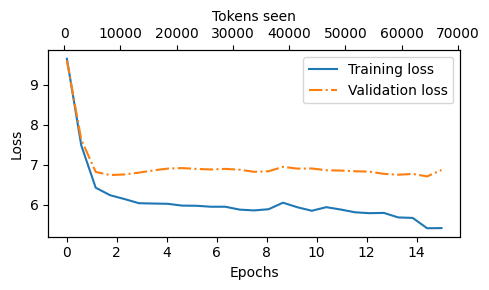

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### Performance after training

In [10]:
import tiktoken
from Utility import text_generation

# Tokenize the text
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "It had always been"
tokenized = tokenizer.encode(start_context)
tokenized_tensor = torch.tensor(tokenized).unsqueeze(0)  
tokenized_tensor = tokenized_tensor.to(device)


model_train.eval()                
out = text_generation(
    model=model_train,
    idx=tokenized_tensor, 
    num_token_generation=40, 
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=0
)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)


It had always been-- to to the to the to-- to the to-- to the to my to-- to-- to-- to to-- to to to-- to-- to the-- to---- to the to


In [ ]:
import tiktoken
from Utility import text_generation

# Tokenize the text
tokenizer = tiktoken.get_encoding("gpt2")
start_context = "Every effort moves you"
tokenized = tokenizer.encode(start_context)
tokenized_tensor = torch.tensor(tokenized).unsqueeze(0)  
tokenized_tensor = tokenized_tensor.to(device)


model_train.eval()                
out = text_generation(
    model=model_train,
    idx=tokenized_tensor, 
    num_token_generation=40, 
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=50,
    temperature=1.5
)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"

















